In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    os.chdir(project_root)

# Simple EDA for Label Studio Export

Quick checks on the parquet export pulled via `scripts/pull_ls.py`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datasets as ds
import tempfile
import imageio.v3 as iio
from IPython.display import Video
from dotenv import load_dotenv
from paths import DATA_DIR

load_dotenv()


True

## Load parquet export

In [3]:

parquet_path = DATA_DIR / 'label_studio_export.parquet'
if not parquet_path.exists():
    raise FileNotFoundError(f"Missing parquet export: {parquet_path}. Run scripts/pull_ls.py first.")

data = pd.read_parquet(parquet_path)
data = data.dropna(subset=['video', 'trick', 'key_foot', 'person']).reset_index(drop=True)
print(f"Loaded {len(data)} labeled rows from {parquet_path}")
data.head()


Loaded 201 labeled rows from /home/tufman/src/uni/aitraf/data/label_studio_export.parquet


,annotation_id,annotator,created_at,id,key_foot,lead_time,person,trick,updated_at,video
0,182,1,2025-11-09T20:58:42.022118Z,477,right,12.241,Max,top-soul,2025-11-09T20:58:42.022134Z,s3://aitraf/clips/25-10-31 19-54-19 5689-00.05...
1,183,1,2025-11-09T20:58:57.738689Z,479,right,8.778,Henrikas,soul,2025-11-09T20:58:57.738699Z,s3://aitraf/clips/25-10-31 19-54-19 5689-00.06...
2,184,1,2025-11-09T20:59:06.227576Z,480,right,7.319,Max,soul,2025-11-09T20:59:06.227592Z,s3://aitraf/clips/25-10-31 19-54-19 5689-00.06...
3,185,1,2025-11-09T20:59:15.438060Z,481,left,8.208,Henrikas,soul,2025-11-09T20:59:15.438071Z,s3://aitraf/clips/25-10-31 19-54-19 5689-00.07...
4,186,1,2025-11-09T20:59:34.346993Z,483,right,9.143,Max,ao-soul,2025-11-09T20:59:34.347009Z,s3://aitraf/clips/25-10-31 19-54-19 5689-00.08...


## Label distribution

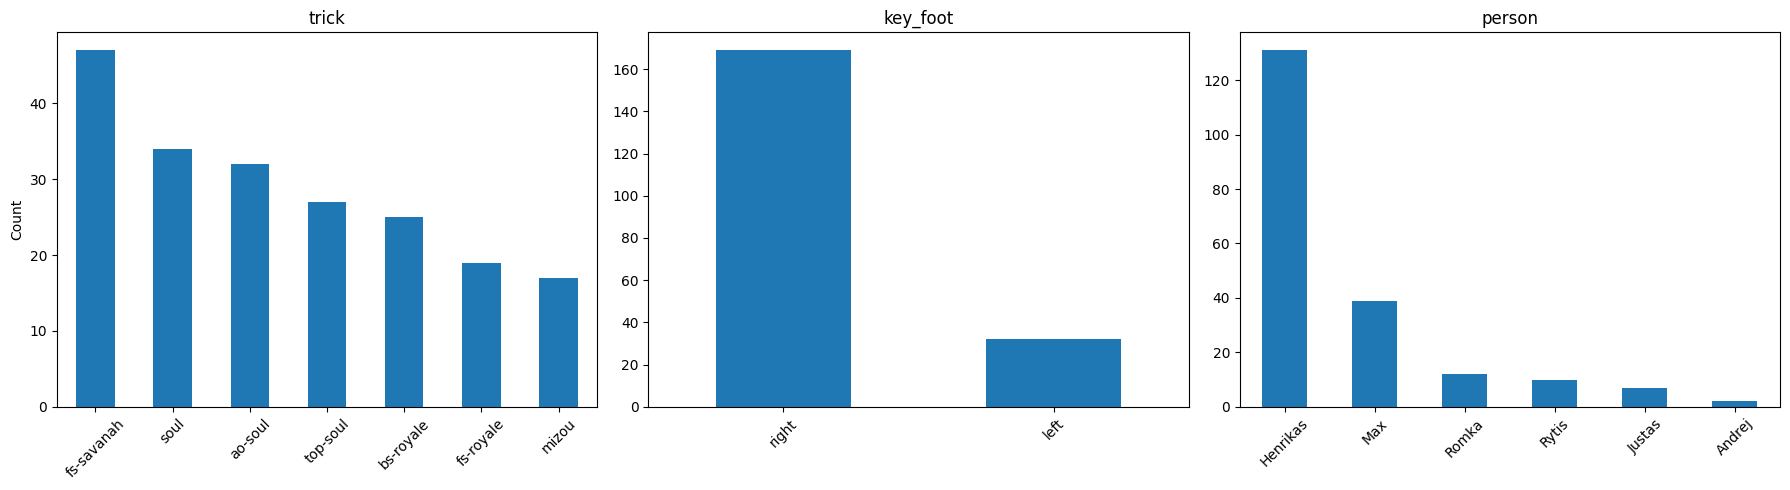

In [4]:

COLS = ['trick', 'key_foot', 'person']
fig, axes = plt.subplots(1, len(COLS), figsize=(6 * len(COLS), 5))
axes = np.atleast_1d(axes)

for i, (ax, col) in enumerate(zip(axes, COLS)):
    counts = data[col].value_counts().sort_values(ascending=False)
    counts.plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Count' if i == 0 else '')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()


## Build Hugging Face dataset

In [5]:

label_names = {
    col: sorted(data[col].astype(str).unique().tolist())
    for col in COLS
}

features = ds.Features({
    'video': ds.Video(),
    **{col: ds.ClassLabel(names=label_names[col]) for col in COLS},
})

hf_dataset = ds.Dataset.from_pandas(
    data[['video'] + COLS],
    features=features,
    preserve_index=False,
)
hf_dataset


Dataset({
    features: ['video', 'trick', 'key_foot', 'person'],
    num_rows: 201
})

## Inspect a sample frame

(np.float64(-0.5), np.float64(1079.5), np.float64(1919.5), np.float64(-0.5))

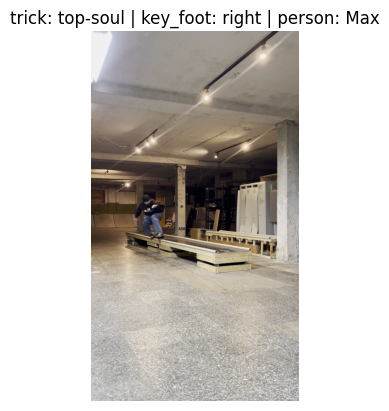

In [6]:

SAMPLE_INDEX = 0

if SAMPLE_INDEX >= len(hf_dataset):
    raise ValueError(f"Dataset has only {len(hf_dataset)} samples; lower SAMPLE_INDEX.")

decoded = hf_dataset.cast_column('video', ds.Video(decode=True, dimension_order='NHWC'))
sample = decoded[SAMPLE_INDEX]
video = np.rot90(sample['video'], 3, axes=(1, 2))

labels = []
for col in COLS:
    feat = hf_dataset.features[col]
    value = sample[col]
    if isinstance(feat, ds.ClassLabel):
        value = feat.int2str(value)
    labels.append(f"{col}: {value}")

label_text = ' | '.join(labels)
frame = video[len(video) // 2]
plt.imshow(frame)
plt.title(label_text)
plt.axis('off')


## Preview video clip

In [8]:
with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as f:
    tmp_path = f.name

iio.imwrite(tmp_path, video, fps=30, codec="libx264", macro_block_size=1)
print(f"Labels: {label_text}\nTemp video: {tmp_path}")
Video(tmp_path, embed=True, width=208)

Labels: trick: top-soul | key_foot: right | person: Max
Temp video: /tmp/tmpdm44f07a.mp4
